In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_rows', None)

In [4]:
df = pd.read_csv("clustering_data.csv").dropna()
STATE = "Uttar Pradesh Circle"
df = df[df["CircleName"] == STATE]

df["Latitude"] = df["Latitude"].apply(lambda x: re.findall(r"-?\d+\.?\d*", str(x))[0]).astype(float)
df["Longitude"] = df["Longitude"].apply(lambda x: re.findall(r"-?\d+\.?\d*", str(x))[0]).astype(float)

/tmp/ipykernel_8358/2224504700.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clustering_data.csv").dropna()


In [5]:
max(df["Longitude"])

8063.0

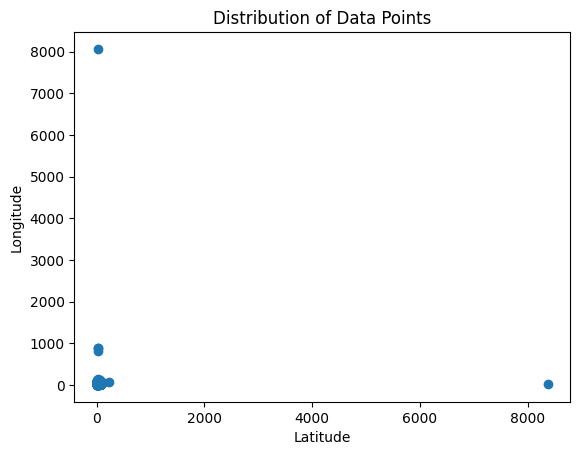

In [6]:
plt.scatter(df["Latitude"], df["Longitude"])
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Distribution of Data Points")
plt.show()

# Clearly from this graph its apparent we have some points being noise. Let's redraw the graph with fixed axes

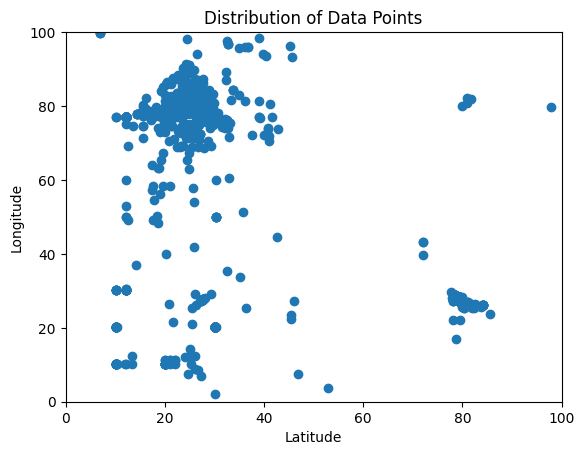

In [7]:
plt.scatter(df["Latitude"], df["Longitude"])
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Distribution of Data Points")
plt.show()

# Clearly from this graph its apparent we have some points being noise. Let's redraw the graph with fixed axes

In [19]:
def k_means(data: np.ndarray, k: int, max_iters=20000):
    # Randomly initialize centroids
    centroids = data[np.random.choice(data.shape[0], k, replace=False)]
    for _ in range(max_iters):
        clusters = [[] for c in centroids]
        # Assign points to the nearest centroid

        for point in data:
            distances = np.linalg.norm(point - centroids, axis=1)
            closest_centroid = np.argmin(distances)
            clusters[closest_centroid].append(point)

        # Update centroids
        new_centroids = np.array([np.array(cluster).mean(axis=0) for cluster in clusters])
        
        # Check for convergence
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return centroids

In [20]:
c = k_means(df[["Latitude", "Longitude"]].values, k=3)

clusters = [[] for _ in c]
for point in df[["Latitude", "Longitude"]].values:
    distances = np.linalg.norm(point - c, axis=1)
    closest_centroid = np.argmin(distances)
    clusters[closest_centroid].append(point)

/tmp/ipykernel_8358/3422545597.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


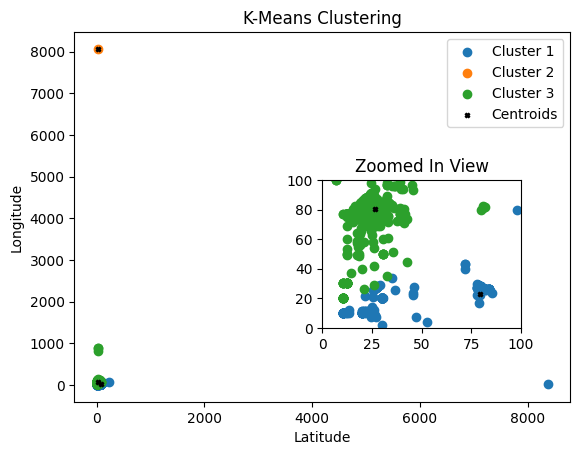

In [34]:
fig, ax = plt.subplots()

ins = ax.inset_axes([0.5, 0.2, 0.4, 0.4])

for i, cluster in enumerate(clusters):
    cluster = np.array(cluster)
    ax.scatter(cluster[:, 0], cluster[:, 1], label=f"Cluster {i+1}")
    ins.scatter(cluster[:, 0], cluster[:, 1], label=f"Cluster {i+1}")
ax.scatter(c[:, 0], c[:, 1], color='black', marker='X', s=10, label='Centroids')
ins.scatter(c[:, 0], c[:, 1], color='black', marker='X', s=10, label='Centroids')
ax.set_xlabel("Latitude")
ax.set_ylabel("Longitude")
ax.set_title("K-Means Clustering")

ins.set_xlim(0, 100)
ins.set_ylim(0, 100)
ins.set_title("Zoomed In View")

ax.legend()
fig.show()

Clearly, due to our noise points that lie on the extremes, our clusters seem to be skewed outwards. This is a common issue with k-means, as it is sensitive to outliers. To mitigate this, we can consider using a more robust clustering algorithm, such as DBSCAN, which can handle noise and outliers more effectively. Alternatively, we could also try preprocessing our data to remove or reduce the influence of these extreme points before applying k-means. Let us try preprocessing the data by removing points that lie outside a certain range of latitude and longitude values, which we can determine based on the distribution of our data. This way, we can focus on the core clusters without being skewed by the outliers.

In [36]:
df.describe()

,Pincode,Latitude,Longitude
count,17177.000000,17177.000000,17177.000000
mean,240742.088607,27.670503,79.957212
std,26410.266085,63.988060,62.418040
min,201001.000000,6.860000,2.100000
25%,221115.000000,25.989060,78.742329
50%,241124.000000,26.855542,80.680000
75%,271401.000000,27.858083,82.270551
max,285223.000000,8377.000000,8063.000000


In [50]:
UTT_LAT_MIN, UTT_LAT_MAX = 23.86667, 31.466667
UTT_LON_MIN, UTT_LON_MAX = 77.5, 84.65

# Let's be a little generous with our limits:
UTT_LAT_MIN -= 3
UTT_LAT_MAX += 3
UTT_LON_MIN -= 3
UTT_LON_MAX += 3

df = df.drop(df[(df["Latitude"] > UTT_LAT_MAX) | (df["Longitude"] > UTT_LON_MAX) | (df["Latitude"] < UTT_LAT_MIN) | (df["Longitude"] < UTT_LON_MIN)].index)

In [52]:
c = k_means(df[["Latitude", "Longitude"]].values, k=3)

clusters = [[] for _ in c]
for point in df[["Latitude", "Longitude"]].values:
    distances = np.linalg.norm(point - c, axis=1)
    closest_centroid = np.argmin(distances)
    clusters[closest_centroid].append(point)

In [54]:
c = k_means(df[["Latitude", "Longitude"]].values, k=3)

clusters = [[] for _ in c]
for point in df[["Latitude", "Longitude"]].values:
    distances = np.linalg.norm(point - c, axis=1)
    closest_centroid = np.argmin(distances)
    clusters[closest_centroid].append(point)

/tmp/ipykernel_8358/1626165989.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


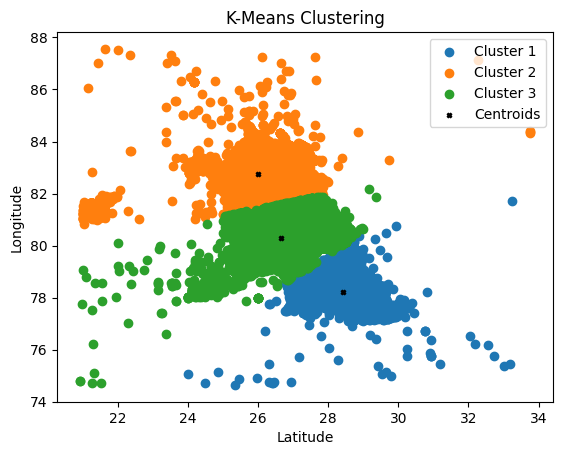

In [56]:
fig, ax = plt.subplots()

for i, cluster in enumerate(clusters):
    cluster = np.array(cluster)
    ax.scatter(cluster[:, 0], cluster[:, 1], label=f"Cluster {i+1}")
ax.scatter(c[:, 0], c[:, 1], color='black', marker='X', s=10, label='Centroids')
ax.set_xlabel("Latitude")
ax.set_ylabel("Longitude")
ax.set_title("K-Means Clustering")

ax.legend()
fig.show()